In [97]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [98]:
# Download data
df1 = yf.download('ADANIGREEN.NS', start="2024-05-22", end="2025-05-22")
df2 = yf.download('BEL.NS', start="2024-05-22", end="2025-05-22")

# Flatten MultiIndex columns if any
if isinstance(df1.columns, pd.MultiIndex):
    df1.columns = df1.columns.get_level_values(0)
if isinstance(df2.columns, pd.MultiIndex):
    df2.columns = df2.columns.get_level_values(0)

# Reset index
df1 = df1.reset_index()
df2 = df2.reset_index()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [99]:
def apply_ema_crossover(df):
    df['EMA_14'] = df['Close'].ewm(span=14, adjust=False).mean()
    df['Signal_EMA'] = 0
    for i in range(1, len(df)):
        if df.loc[i, 'Close'] > df.loc[i, 'EMA_14'] and df.loc[i-1, 'Close'] <= df.loc[i-1, 'EMA_14']:
            df.loc[i, 'Signal_EMA'] = 1
        elif df.loc[i, 'Close'] < df.loc[i, 'EMA_14'] and df.loc[i-1, 'Close'] >= df.loc[i-1, 'EMA_14']:
            df.loc[i, 'Signal_EMA'] = -1
    return df

In [100]:
def apply_ema_dynamic_band(df):
    df['Band_Range'] = df['High'] - df['Low']
    df['Buy_Band'] = df['EMA_14'] + df['Band_Range']
    df['Sell_Band'] = df['EMA_14'] - df['Band_Range']
    df['Signal_DynBand'] = 0
    for i in range(1, len(df)):
        if df.loc[i, 'Close'] > df.loc[i, 'Buy_Band']:
            df.loc[i, 'Signal_DynBand'] = 1
        elif df.loc[i, 'Close'] < df.loc[i, 'Sell_Band']:
            df.loc[i, 'Signal_DynBand'] = -1
    return df

In [101]:
def apply_atr_breakout(df, k=1.5):
    df['Prev_Close'] = df['Close'].shift(1)

    df['TR1'] = df['High'] - df['Low']
    df['TR2'] = (df['High'] - df['Prev_Close']).abs()
    df['TR3'] = (df['Low'] - df['Prev_Close']).abs()
    df['TR'] = df[['TR1', 'TR2', 'TR3']].max(axis=1)

    df['ATR_14'] = df['TR'].ewm(span=14, adjust=False).mean()
    df['ATR_Buy_Band'] = df['EMA_14'] + k * df['ATR_14']
    df['ATR_Sell_Band'] = df['EMA_14'] - k * df['ATR_14']

    df['Signal_ATR'] = 0
    for i in range(1, len(df)):
        if df.loc[i, 'Close'] > df.loc[i, 'ATR_Buy_Band']:
            df.loc[i, 'Signal_ATR'] = 1
        elif df.loc[i, 'Close'] < df.loc[i, 'ATR_Sell_Band']:
            df.loc[i, 'Signal_ATR'] = -1

    df.drop(columns=['TR1', 'TR2', 'TR3'], inplace=True)
    return df


In [102]:
def backtest_strategy(data, signal_col, initial_capital=100000):
    data = data.copy()

    if isinstance(data[signal_col], pd.DataFrame):
        raise ValueError(f"Expected a Series for signal_col='{signal_col}', got a DataFrame instead.")

    # Directly use signal values: 1 (Buy), -1 (Sell), 0 (Hold)
    data['Position'] = data[signal_col].copy()
    data['Position'] = data['Position'].replace(to_replace=0, method='ffill').fillna(0)

    trades = []
    daily_logs = []

    capital = initial_capital
    shares = 0
    entry_index = None
    entry_price = 0

    for i in range(1, len(data)):
        date = data['Date'].iloc[i]
        price = data['Close'].iloc[i]
        position = data['Position'].iloc[i]

        # Check for change in position (entry/exit)
        if data['Position'].iloc[i] != data['Position'].iloc[i - 1]:
            if shares != 0:
                # Exit trade
                exit_price = price
                ret_pct = ((exit_price - entry_price) / entry_price * 100) if shares > 0 else ((entry_price - exit_price) / entry_price * 100)
                capital += shares * exit_price
                trade_df = data.iloc[entry_index:i+1]
                drawdowns = (trade_df['Close'].cummax() - trade_df['Close']) / trade_df['Close'].cummax() * 100
                dips = (entry_price - trade_df['Close']) / entry_price * 100

                trades.append({
                    'Entry Index': entry_index,
                    'Exit Index': i,
                    'Entry Date': data['Date'].iloc[entry_index],
                    'Exit Date': date,
                    'Trade Duration': i - entry_index,
                    'Returns (%)': round(ret_pct, 2),
                    'Type': 'Long' if shares > 0 else 'Short',
                    'Max Drawdown (%)': round(drawdowns.max(), 2),
                    'Max Dip (%)': round(dips.max(), 2),
                    'Quantity': abs(shares)
                })

                shares = 0  # Reset shares after exit

            # Enter new trade
            if position != 0:
                entry_index = i
                entry_price = price
                shares = (capital // price) * position
                capital -= shares * price

        # Daily portfolio value
        portfolio_value = capital + shares * price
        daily_logs.append({
            'Date': date,
            'Portfolio Value': portfolio_value,
            'Shares Held': shares,
            'Profit (%)': (portfolio_value - initial_capital) / initial_capital * 100
        })

    trades_df = pd.DataFrame(trades)
    daily_df = pd.DataFrame(daily_logs)
    return trades_df, daily_df


In [103]:
def compute_metrics(trades_df, daily_df, benchmark_returns):
    win_trades = trades_df[trades_df['Returns (%)'] > 0]
    loss_trades = trades_df[trades_df['Returns (%)'] <= 0]

    avg_drawdown = trades_df['Max Drawdown (%)'].mean()
    avg_dip = trades_df['Max Dip (%)'].mean()

    metrics = {
        'Benchmark Returns (%)': round(benchmark_returns, 2),
        'Net Profit (%)': round(daily_df['Profit (%)'].iloc[-1], 2),
        'Gross Profit (%)': round(trades_df['Returns (%)'].sum(), 2),
        'Number of Trades': len(trades_df),
        'Winning Trades': len(win_trades),
        'Losing Trades': len(loss_trades),
        'Max Holding Time': trades_df['Trade Duration'].max(),
        'Avg Holding Time': round(trades_df['Trade Duration'].mean(), 2),
        'Max Drawdown (%)': trades_df['Max Drawdown (%)'].max(),
        'Avg Drawdown (%)': round(avg_drawdown, 2),
        'Max Dip (%)': trades_df['Max Dip (%)'].max(),
        'Avg Dip (%)': round(avg_dip, 2),
        'Sharpe Ratio': round(daily_df['Profit (%)'].mean() / daily_df['Profit (%)'].std(), 2) if daily_df['Profit (%)'].std() != 0 else 0
    }

    return metrics


In [104]:
def plot_strategy(data, daily_df, trades_df, title="Backtest Performance"):
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    axs[0].plot(data['Date'], data['Close'], label='Close Price', color='black')
    for _, row in trades_df.iterrows():
        axs[0].axvline(x=row['Entry Date'], color='green', linestyle='--', alpha=0.6)
        axs[0].axvline(x=row['Exit Date'], color='red', linestyle='--', alpha=0.6)
    axs[0].set_title(f'{title} - Entry/Exit Points')
    axs[0].legend()

    axs[1].plot(daily_df['Date'], daily_df['Portfolio Value'], color='blue', label='Portfolio Value')
    axs[1].set_title(f'{title} - Portfolio Value Over Time')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

 Backtesting on Dataset 1
EMA Crossover on Dataset 1
Benchmark Returns (%): -46.61
Net Profit (%): -17.6
Gross Profit (%): -17.54
Number of Trades: 32
Winning Trades: 8
Losing Trades: 24
Max Holding Time: 30
Avg Holding Time: 7.47
Max Drawdown (%): 45.3
Avg Drawdown (%): 7.16
Max Dip (%): 45.3
Avg Dip (%): 5.95
Sharpe Ratio: -1.35


<ipython-input-102-8db07008c025>:9: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['Position'] = data['Position'].replace(to_replace=0, method='ffill').fillna(0)


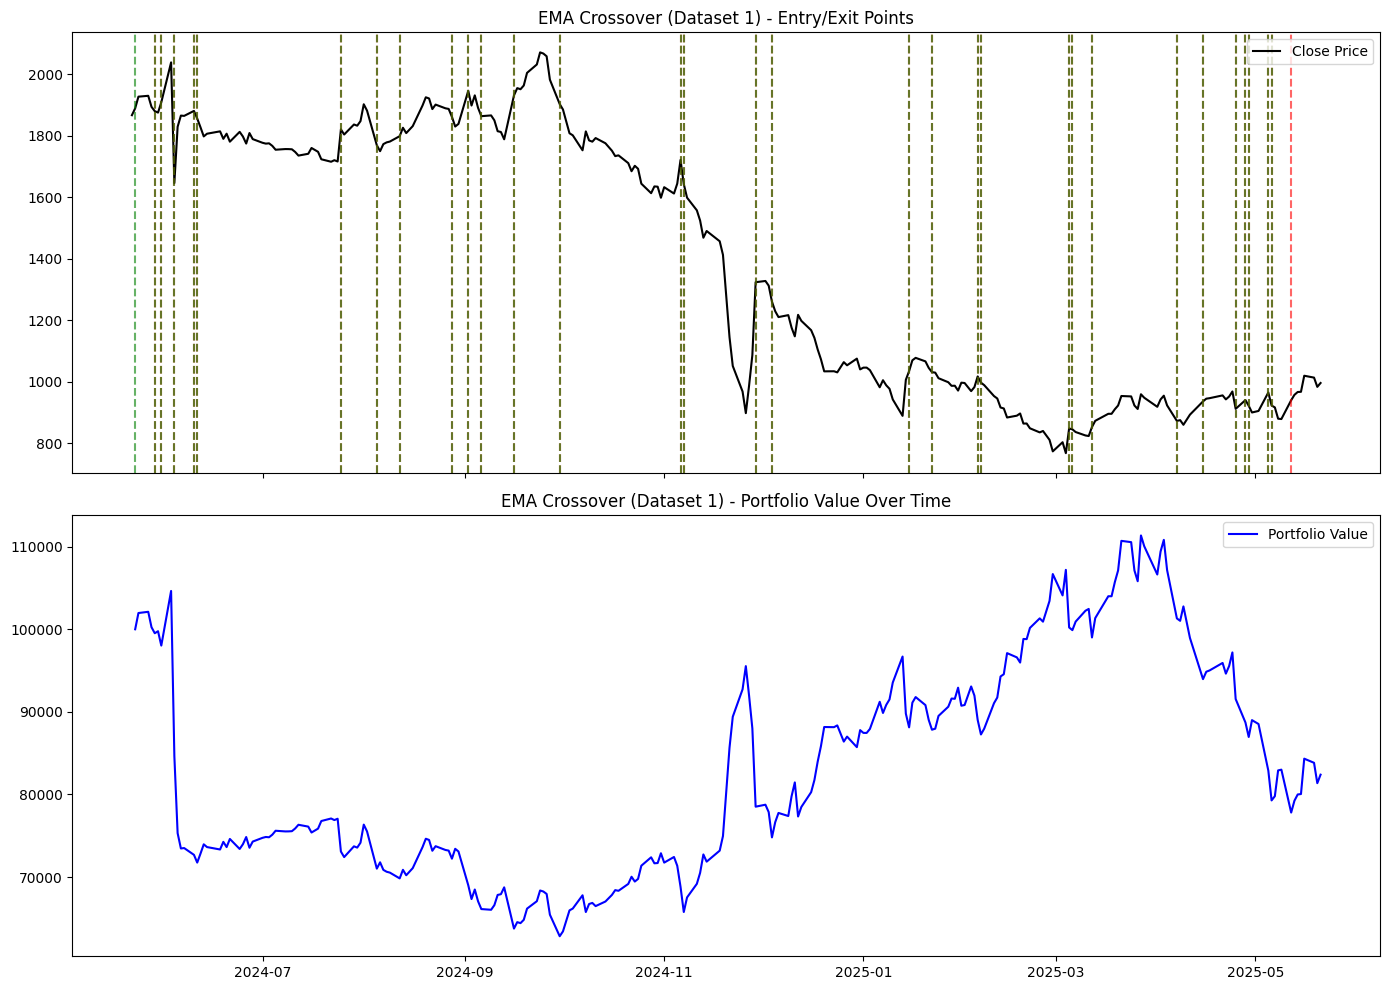

<ipython-input-102-8db07008c025>:9: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['Position'] = data['Position'].replace(to_replace=0, method='ffill').fillna(0)


Dynamic Band on Dataset 1
Benchmark Returns (%): -46.61
Net Profit (%): -2.44
Gross Profit (%): 3.83
Number of Trades: 11
Winning Trades: 2
Losing Trades: 9
Max Holding Time: 74
Avg Holding Time: 20.45
Max Drawdown (%): 52.8
Avg Drawdown (%): 11.67
Max Dip (%): 52.8
Avg Dip (%): 9.88
Sharpe Ratio: 0.72


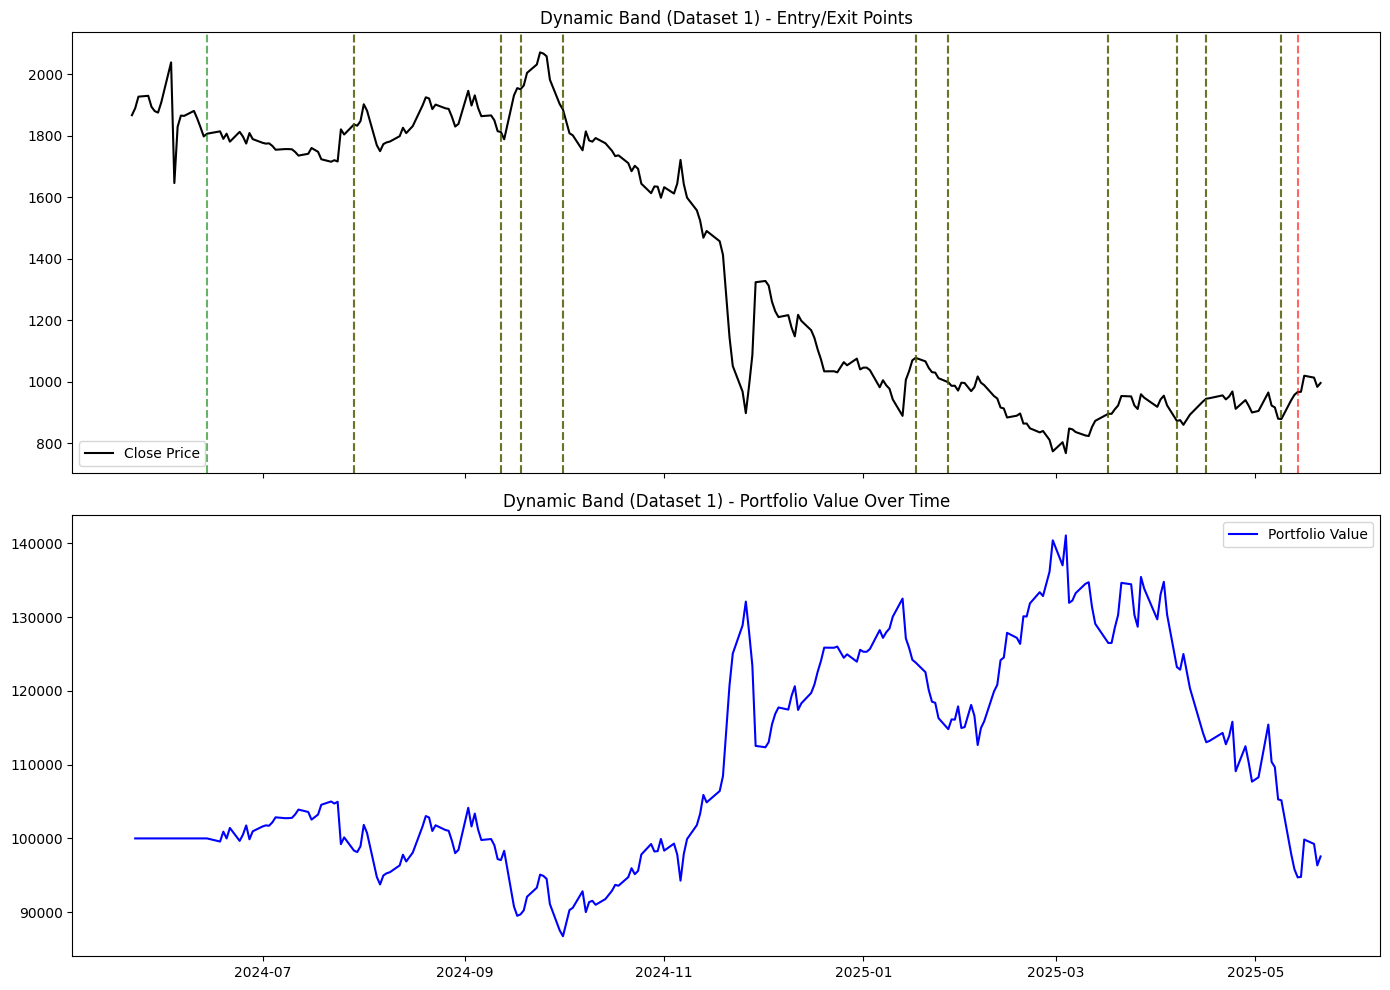

<ipython-input-102-8db07008c025>:9: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['Position'] = data['Position'].replace(to_replace=0, method='ffill').fillna(0)


ATR Breakout on Dataset 1
Benchmark Returns (%): -46.61
Net Profit (%): -15.63
Gross Profit (%): -6.42
Number of Trades: 4
Winning Trades: 1
Losing Trades: 3
Max Holding Time: 117
Avg Holding Time: 50.25
Max Drawdown (%): 57.63
Avg Drawdown (%): 24.58
Max Dip (%): 57.49
Avg Dip (%): 21.93
Sharpe Ratio: -2.8


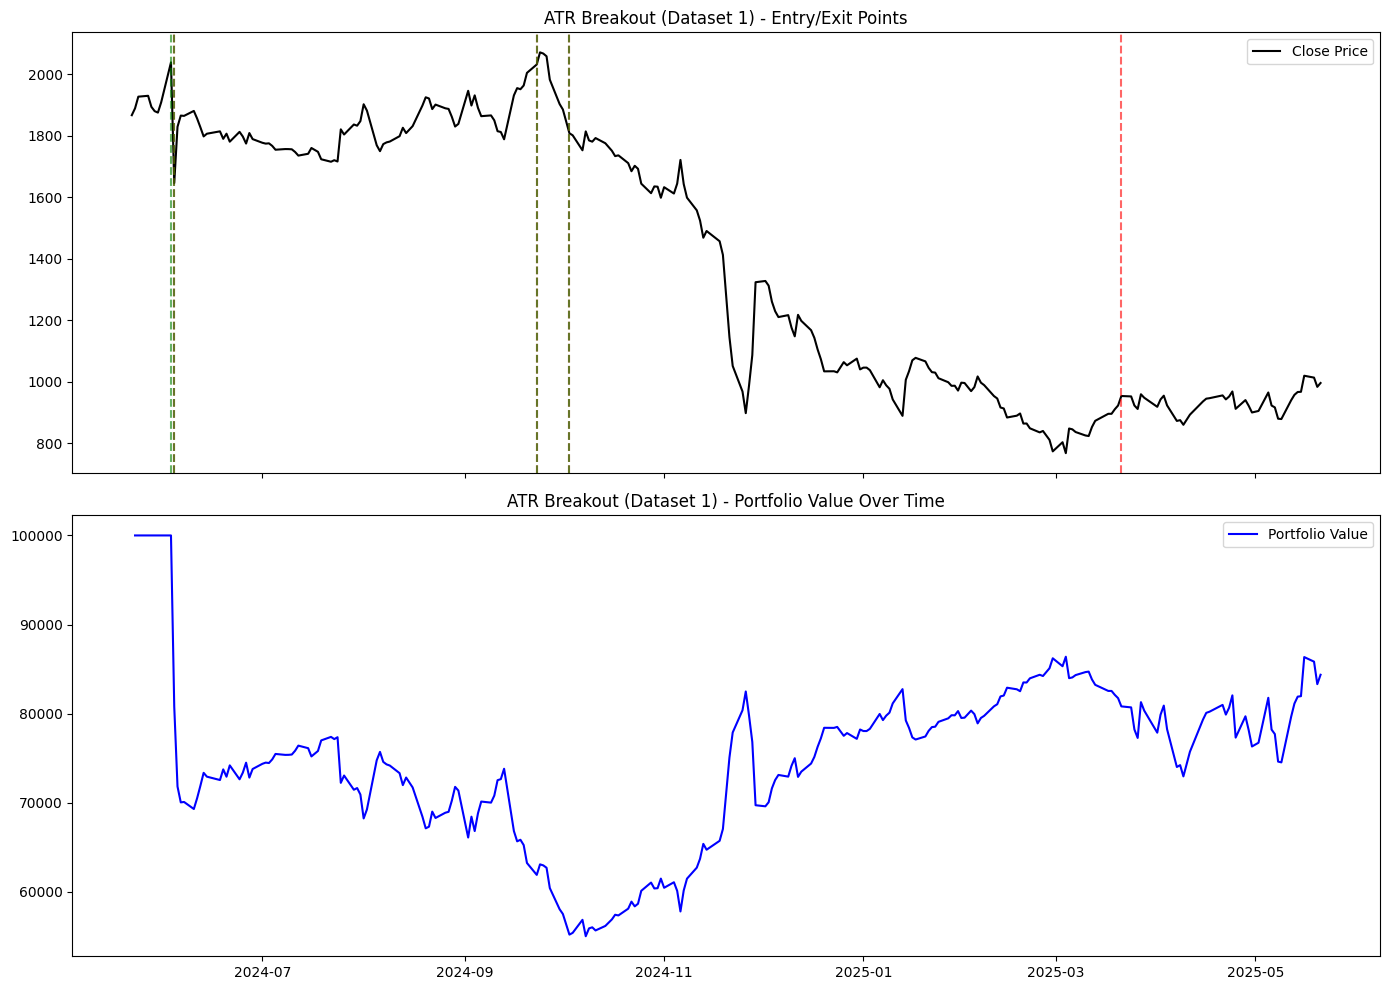

 Backtesting on Dataset 2
EMA Crossover on Dataset 2
Benchmark Returns (%): 36.17
Net Profit (%): 27.36
Gross Profit (%): -1.92
Number of Trades: 26
Winning Trades: 8
Losing Trades: 18
Max Holding Time: 27
Avg Holding Time: 8.5
Max Drawdown (%): 19.8
Avg Drawdown (%): 5.43
Max Dip (%): 14.55
Avg Dip (%): 3.71
Sharpe Ratio: -1.22


<ipython-input-102-8db07008c025>:9: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['Position'] = data['Position'].replace(to_replace=0, method='ffill').fillna(0)


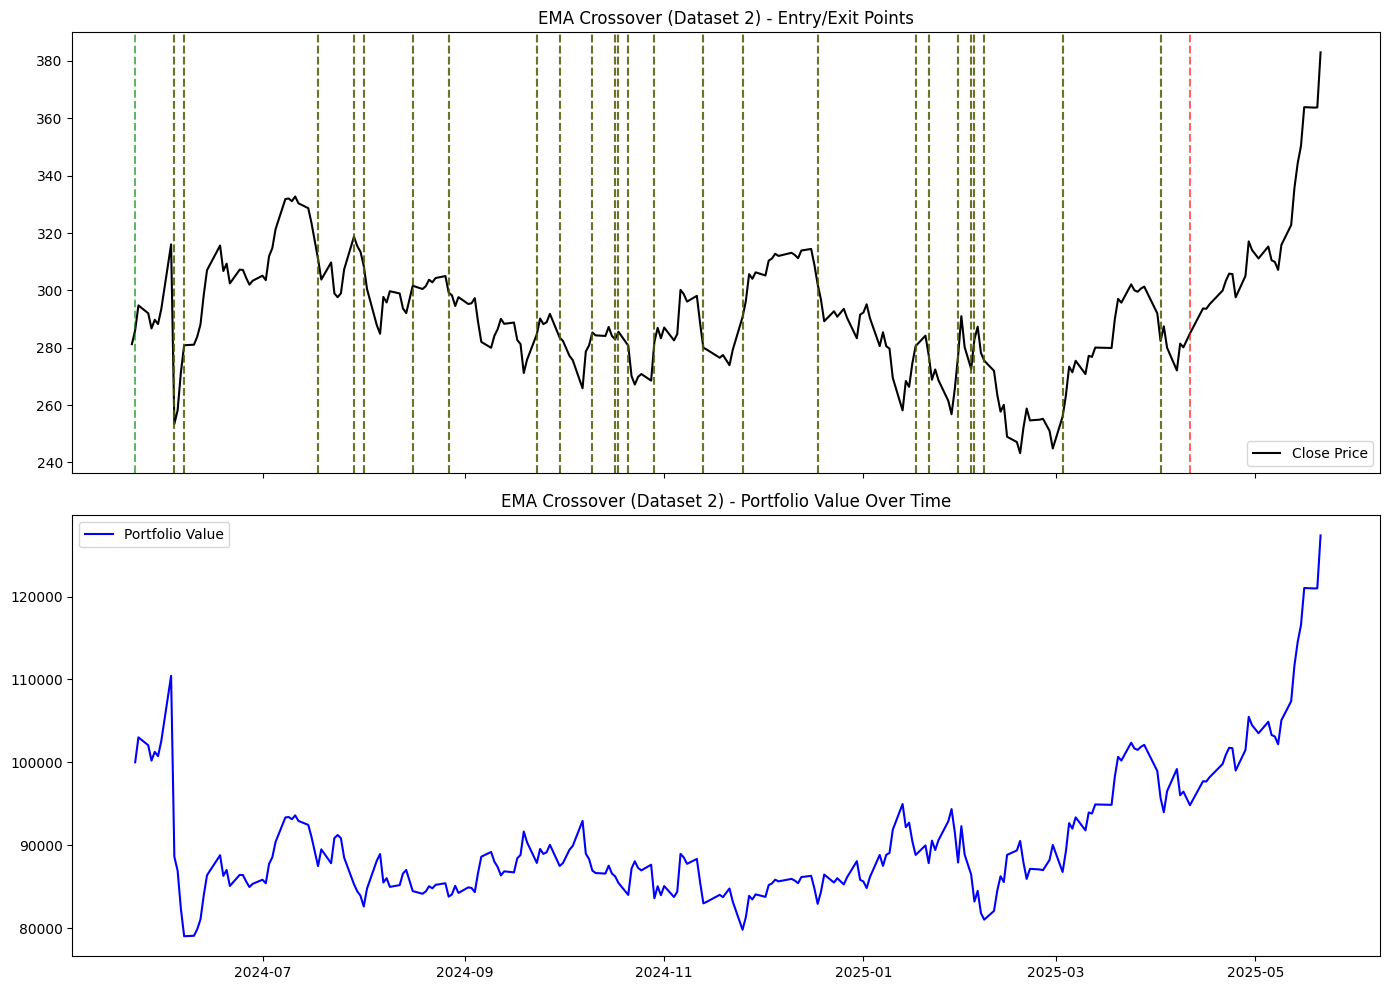

<ipython-input-102-8db07008c025>:9: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['Position'] = data['Position'].replace(to_replace=0, method='ffill').fillna(0)


Dynamic Band on Dataset 2
Benchmark Returns (%): 36.17
Net Profit (%): -18.18
Gross Profit (%): -51.8
Number of Trades: 12
Winning Trades: 2
Losing Trades: 10
Max Holding Time: 32
Avg Holding Time: 15.83
Max Drawdown (%): 19.8
Avg Drawdown (%): 8.34
Max Dip (%): 19.8
Avg Dip (%): 6.79
Sharpe Ratio: -1.49


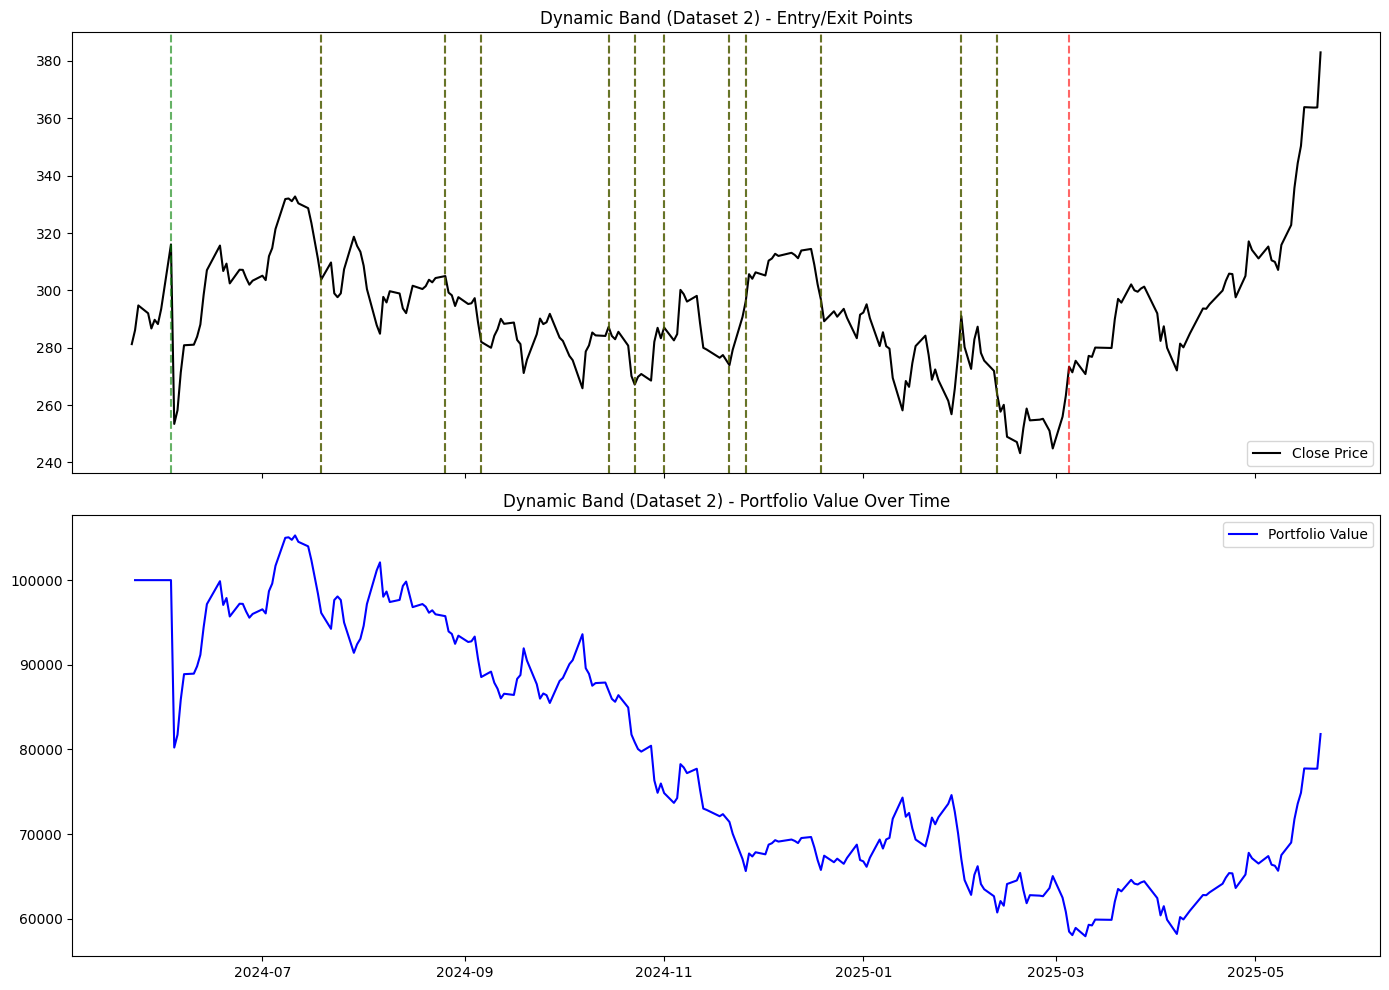

<ipython-input-102-8db07008c025>:9: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['Position'] = data['Position'].replace(to_replace=0, method='ffill').fillna(0)


ATR Breakout on Dataset 2
Benchmark Returns (%): 36.17
Net Profit (%): -21.23
Gross Profit (%): -48.38
Number of Trades: 6
Winning Trades: 0
Losing Trades: 6
Max Holding Time: 65
Avg Holding Time: 33.17
Max Drawdown (%): 19.8
Avg Drawdown (%): 12.37
Max Dip (%): 19.8
Avg Dip (%): 10.69
Sharpe Ratio: -1.23


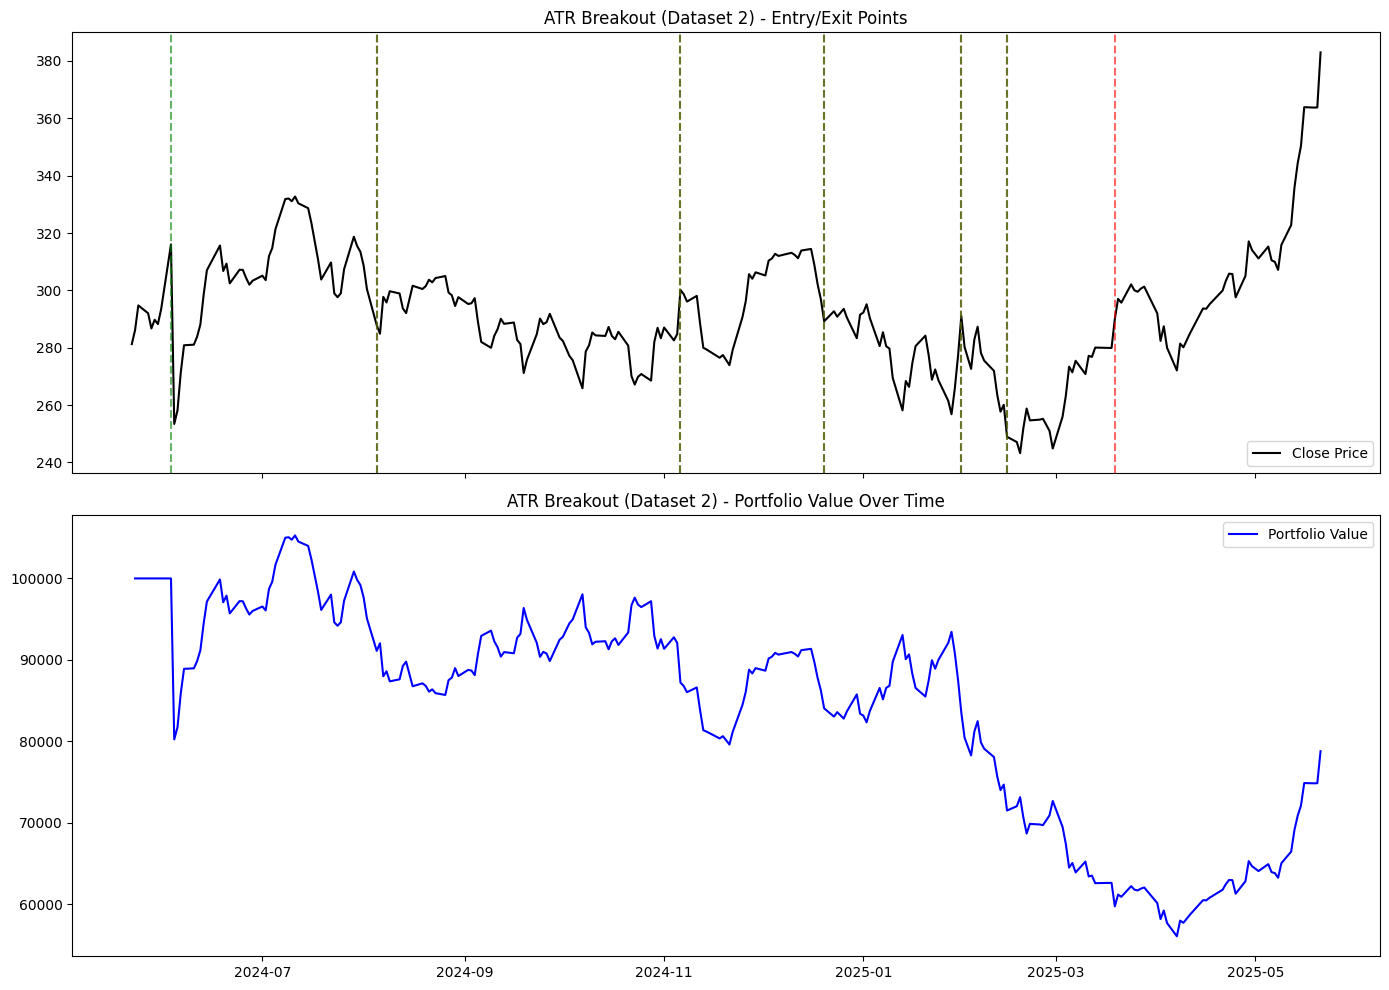

In [105]:
# Apply all strategies to both datasets
for df in [df1, df2]:
    apply_ema_crossover(df)
    apply_ema_dynamic_band(df)
    apply_atr_breakout(df)

# Backtest all strategies on both datasets
for df, label in [(df1, "Dataset 1"), (df2, "Dataset 2")]:
    print(f" Backtesting on {label}")
    for strategy, signal_col in {
        'EMA Crossover': 'Signal_EMA',
        'Dynamic Band': 'Signal_DynBand',
        'ATR Breakout': 'Signal_ATR'
    }.items():
        trades_df, daily_df = backtest_strategy(df, signal_col)
        benchmark = (df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0] * 100
        metrics = compute_metrics(trades_df, daily_df, benchmark)

        print(f"{strategy} on {label}")
        for key, value in metrics.items():
            print(f"{key}: {value}")
        plot_strategy(df, daily_df, trades_df, title=f"{strategy} ({label})")


In [106]:
url = "https://raw.githubusercontent.com/VolatilityVoyage-FAC-SummerProject-2025/backtesting-introtohedging-hk-365/refs/heads/main/hist_india_vix_-22-05-2024-to-22-05-2025.csv?token=GHSAT0AAAAAADDX5KP2FECU2GEZDIXMQ2DS2BVGNUA"


In [107]:
vix_df = pd.read_csv(url)
vix_df.columns = vix_df.columns.str.strip()  # Clean column names
vix_df["Date"] = pd.to_datetime(vix_df["Date"], format="%d-%b-%Y")
vix_df.set_index("Date", inplace=True)

In [108]:
vix_mean = vix_df["Close"].mean()
vix_std = vix_df["Close"].std()

threshold1 = vix_mean + 0.5 * vix_std
threshold2 = vix_mean + 1.5 * vix_std

In [109]:
def allocation_from_vix(vix_val):
    if vix_val < threshold1:
        return 1.0
    elif vix_val < threshold2:
        return 0.75
    else:
        return 0.5

vix_df['Allocation'] = vix_df['Close'].apply(allocation_from_vix)

In [110]:

def backtest_strategy_dynamic_allocation(data, signal_col='Signal_ATR', allocation_col='Allocation', initial_capital=100000):
    data = data.copy()
    data['Position'] = data[signal_col].replace(0, np.nan).ffill().fillna(0)

    trades = []
    daily_logs = []

    capital = initial_capital
    shares = 0
    entry_index = None
    entry_price = 0

    for i in range(1, len(data)):
        date = data['Date'].iloc[i]
        price = data['Close'].iloc[i]
        position = data['Position'].iloc[i]
        allocation = data[allocation_col].iloc[i]

        if data['Position'].iloc[i] != data['Position'].iloc[i - 1]:
            if shares != 0:
                exit_price = price
                ret_pct = ((exit_price - entry_price) / entry_price * 100) if shares > 0 else ((entry_price - exit_price) / entry_price * 100)
                capital += shares * exit_price
                trade_df = data.iloc[entry_index:i+1]
                drawdowns = (trade_df['Close'].cummax() - trade_df['Close']) / trade_df['Close'].cummax() * 100
                dips = (entry_price - trade_df['Close']) / entry_price * 100

                trades.append({
                    'Entry Index': entry_index,
                    'Exit Index': i,
                    'Entry Date': data['Date'].iloc[entry_index],
                    'Exit Date': date,
                    'Trade Duration': i - entry_index,
                    'Returns (%)': round(ret_pct, 2),
                    'Type': 'Long' if shares > 0 else 'Short',
                    'Max Drawdown (%)': round(drawdowns.max(), 2),
                    'Max Dip (%)': round(dips.max(), 2),
                    'Quantity': abs(shares)
                })

                shares = 0

            if position != 0:
                entry_index = i
                entry_price = price
                capital_to_invest = capital * allocation
                shares = (capital_to_invest // price) * position
                capital -= shares * price

        portfolio_value = capital + shares * price
        daily_logs.append({
            'Date': date,
            'Portfolio Value': portfolio_value,
            'Shares Held': shares,
            'Profit (%)': (portfolio_value - initial_capital) / initial_capital * 100
        })

    trades_df = pd.DataFrame(trades)
    daily_df = pd.DataFrame(daily_logs)
    return trades_df, daily_df

In [111]:
def calculate_metrics(daily_df, initial_capital=100000, risk_free_rate=0.05):
    daily_df = daily_df.copy()
    daily_df['Daily Return'] = daily_df['Portfolio Value'].pct_change().fillna(0)

    total_return = (daily_df['Portfolio Value'].iloc[-1] - initial_capital) / initial_capital * 100
    max_drawdown = ((daily_df['Portfolio Value'].cummax() - daily_df['Portfolio Value']) / daily_df['Portfolio Value'].cummax()).max() * 100

    # Sharpe Ratio (Annualized)
    avg_daily_ret = daily_df['Daily Return'].mean()
    std_daily_ret = daily_df['Daily Return'].std()
    sharpe_ratio = ((avg_daily_ret - risk_free_rate / 252) / std_daily_ret) * np.sqrt(252) if std_daily_ret != 0 else 0

    # Value at Risk (VaR) and Conditional VaR (CVaR) at 95% confidence
    var_95 = np.percentile(daily_df['Daily Return'], 5)
    cvar_95 = daily_df[daily_df['Daily Return'] <= var_95]['Daily Return'].mean()

    return {
        'Net Return (%)': round(total_return, 2),
        'Max Drawdown (%)': round(max_drawdown, 2),
        'Sharpe Ratio': round(sharpe_ratio, 2),
        'VaR (95%)': round(var_95 * 100, 2),
        'CVaR (95%)': round(cvar_95 * 100, 2)
    }


In [112]:
def merge_allocation(price_df):
    merged = price_df.copy()
    merged['Allocation'] = 1.0
    return merged


# Fixed allocation (always 100%)
df1_fixed = df1.copy()
df1_fixed['Allocation'] = 1.0

df2_fixed = df2.copy()
df2_fixed['Allocation'] = 1.0

df1 = merge_allocation(df1)
trades1, daily1 = backtest_strategy_dynamic_allocation(df1)

df2 = merge_allocation(df2)
trades2, daily2 = backtest_strategy_dynamic_allocation(df2)

# Backtest with fixed allocation
trades1_fixed, daily1_fixed = backtest_strategy_dynamic_allocation(df1_fixed)
trades2_fixed, daily2_fixed = backtest_strategy_dynamic_allocation(df2_fixed)


In [114]:
print("\nPerformance Summary:")

print("\nAdani Green (Dynamic Allocation):")
print(calculate_metrics(daily1))

print("\nBel (Dynamic Allocation):")
print(calculate_metrics(daily2))



Performance Summary:

Adani Green (Dynamic Allocation):
{'Net Return (%)': np.float64(-15.63), 'Max Drawdown (%)': 44.97, 'Sharpe Ratio': np.float64(-0.29), 'VaR (95%)': np.float64(-3.96), 'CVaR (95%)': np.float64(-7.34)}

Bel (Dynamic Allocation):
{'Net Return (%)': np.float64(-21.23), 'Max Drawdown (%)': 46.77, 'Sharpe Ratio': np.float64(-0.56), 'VaR (95%)': np.float64(-3.69), 'CVaR (95%)': np.float64(-5.53)}
